
# Adult Income — Simple, Commented ML Lifecycle (Fixed)

We keep things **simple** and **explain every step** to match your project description:
1) Load & clean data + quick EDA  
2) Leakage-safe preprocessing (`ColumnTransformer` + `Pipeline`)  
3) Two baseline models: Logistic Regression & Random Forest  
4) Metrics & plots (ACC, PREC, REC, F1, ROC-AUC; Confusion Matrix & ROC)  
5) Permutation importance (top features)  
6) Save final model  


## 0) Imports & Setup

In [1]:

import warnings, os, pathlib
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import joblib

BASE = pathlib.Path('.').resolve()
DATA = BASE / 'data'
REPORTS = BASE / 'reports' / 'figures'
MODELS = BASE / 'models'
REPORTS.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)
print('Data directory:', DATA)


Data directory: /home/AnirSaddik/Desktop/Year3/Semester1/Data5/Term1/Project/to-check-poject/Fixed_Simple_Adult_Project/notebooks/data


## 1) Load the Adult dataset (kept simple)

In [3]:

# 👉 Set this if your filename is different (e.g., 'data/adult.data' or 'data/adult.csv')
DATA_PATH = '../data/adult.data'  # e.g., 'data/adult.data' or 'data/adult.csv'

# UCI Adult columns (for .data without header)
COLS = [
    "age","workclass","fnlwgt","education","education-num",
    "marital-status","occupation","relationship","race","sex",
    "capital-gain","capital-loss","hours-per-week","native-country","income"
]

def load_adult_simple(data_dir: pathlib.Path, data_path: str | None):
    """Minimal loader: if DATA_PATH is set, use it; else try common adult.* names in ./data."""
    # 1) If user specified a file path explicitly
    if data_path:
        p = pathlib.Path(data_path)
        if not p.exists():
            raise FileNotFoundError(f"DATA_PATH not found: {p}")
        if p.suffix.lower() == '.data':
            df_ = pd.read_csv(p, header=None, names=COLS, na_values='?', skipinitialspace=True)
        else:
            df_ = pd.read_csv(p, na_values='?')
        return df_
    # 2) Try typical UCI/Kaggle names
    candidates = [
        data_dir / 'adult.csv',
        data_dir / 'adult.data',
        data_dir / 'adult_test.csv',
        data_dir / 'adult.test',
    ]
    for p in candidates:
        if p.exists():
            if p.suffix.lower() == '.data' or p.name.lower().endswith('.test'):
                return pd.read_csv(p, header=None, names=COLS, na_values='?', skipinitialspace=True, comment='|')
            else:
                return pd.read_csv(p, na_values='?')
    # 3) Fallback: first csv/data in data/
    for p in data_dir.glob('*'):
        if p.suffix.lower() in {'.csv', '.data'}:
            if p.suffix.lower() == '.data':
                return pd.read_csv(p, header=None, names=COLS, na_values='?', skipinitialspace=True)
            else:
                return pd.read_csv(p, na_values='?')
    raise FileNotFoundError("No Adult file found. Put a CSV or adult.data in ./data (or set DATA_PATH)." )

df = load_adult_simple(DATA, DATA_PATH)

# Normalize common column name variants
df = df.rename(columns={
    "capital_gain":"capital-gain",
    "capital_loss":"capital-loss",
    "hours_per_week":"hours-per-week",
    "education_num":"education-num",
    "marital_status":"marital-status",
    "native_country":"native-country",
    "class":"income","target":"income","salary":"income"
})

# Strip whitespace from strings
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()

# Ensure target exists
if 'income' not in df.columns:
    raise ValueError("Target column 'income' not found. Rename your target to 'income'.")

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} cols")
df.head()


Loaded: 32561 rows, 15 cols


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2) Quick EDA & Cleaning (very light)

Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical (first 10): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


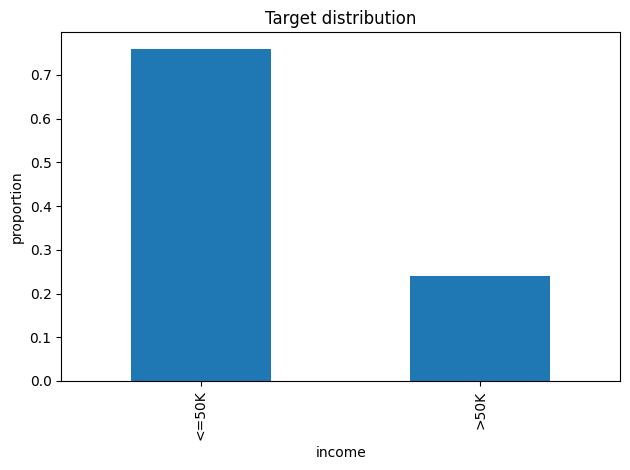

In [4]:

# Replace '?' already handled by na_values, but double-sure:
df = df.replace('?', pd.NA)

# Build X, y
y = df['income'].astype(str).str.strip().apply(lambda v: '>50K' if v in {'>50K','>50K.'} else '<=50K')
X = df.drop(columns=['income'])

# Identify types
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]
print('Numeric columns:', numeric_cols)
print('Categorical (first 10):', categorical_cols[:10])

# Class balance viz
y.value_counts(normalize=True).plot(kind='bar', title='Target distribution'); plt.ylabel('proportion')
plt.tight_layout(); plt.savefig(REPORTS/'target_distribution.png'); plt.show()


## 3) Leakage-safe preprocessing

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    [
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols)
    ],
    sparse_threshold=0.0  # return dense array to keep everything simple
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## 4) Two baseline models (LogReg & RandomForest)

In [6]:

logreg = Pipeline([("preprocess", preprocess),
                   ("clf", LogisticRegression(max_iter=500, class_weight="balanced"))])

rf = Pipeline([("preprocess", preprocess),
               ("clf", RandomForestClassifier(n_estimators=300, random_state=42,
                                             n_jobs=-1, class_weight="balanced"))])

logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)

best_models = {"logreg": logreg, "rf": rf}


## 5) Evaluate models (metrics + plots)

logreg: ACC=0.812 PRE=0.574 REC=0.853 F1=0.686 ROC-AUC=0.909
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.87      4945
        >50K       0.57      0.85      0.69      1568

    accuracy                           0.81      6513
   macro avg       0.76      0.83      0.78      6513
weighted avg       0.86      0.81      0.82      6513



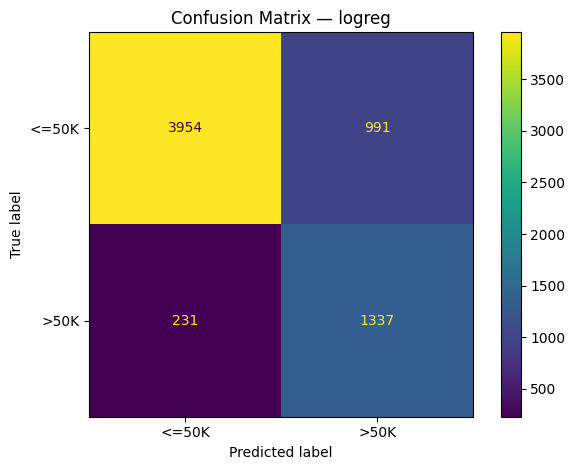

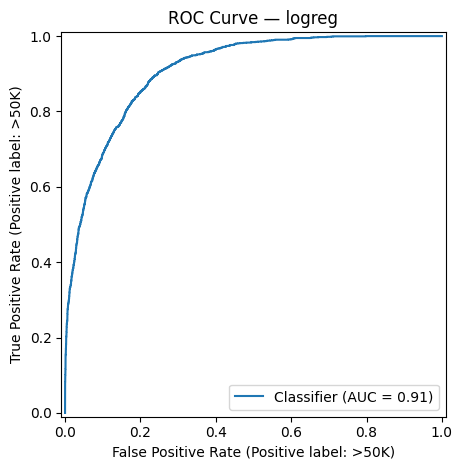

rf: ACC=0.860 PRE=0.749 REC=0.630 F1=0.684 ROC-AUC=0.908
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4945
        >50K       0.75      0.63      0.68      1568

    accuracy                           0.86      6513
   macro avg       0.82      0.78      0.80      6513
weighted avg       0.85      0.86      0.86      6513



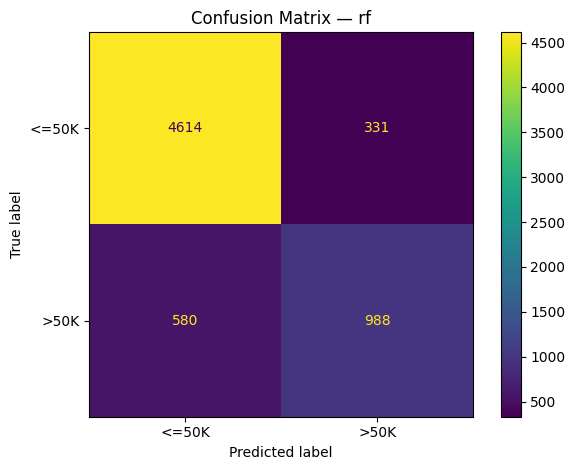

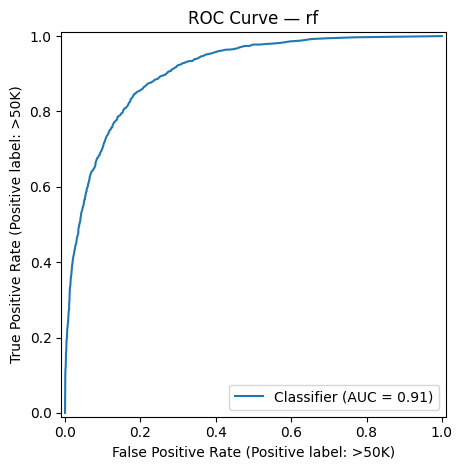

,acc,pre,rec,f1,roc_auc
logreg,0.812375,0.574313,0.852679,0.686345,0.909423
rf,0.860126,0.749052,0.630102,0.684448,0.907711


In [8]:

def evaluate_model(model, X_te, y_te, label):
    y_pred = model.predict(X_te)

    # probabilities or decision scores for ROC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_te)
    else:
        y_score = None

    acc = accuracy_score(y_te, y_pred)
    pre = precision_score(y_te, y_pred, pos_label=">50K")
    rec = recall_score(y_te, y_pred, pos_label=">50K")
    f1  = f1_score(y_te, y_pred, pos_label=">50K")
    roc = roc_auc_score(y_te, y_score) if y_score is not None else np.nan

    print(f"{label}: ACC={acc:.3f} PRE={pre:.3f} REC={rec:.3f} F1={f1:.3f} ROC-AUC={roc:.3f}")
    print(classification_report(y_te, y_pred))

    cm = confusion_matrix(y_te, y_pred, labels=["<=50K", ">50K"]) 
    ConfusionMatrixDisplay(cm, display_labels=["<=50K", ">50K"]).plot(values_format='d')
    plt.title(f"Confusion Matrix — {label}"); plt.tight_layout()
    plt.savefig(REPORTS / f"cm_{label}.png"); plt.show()

    if y_score is not None:
        RocCurveDisplay.from_predictions(y_te, y_score, pos_label=">50K")
        plt.title(f"ROC Curve — {label}"); plt.tight_layout()
        plt.savefig(REPORTS / f"roc_{label}.png"); plt.show()

    return {"acc":acc, "pre":pre, "rec":rec, "f1":f1, "roc_auc":roc}

scores = {}
for name, model in best_models.items():
    scores[name] = evaluate_model(model, X_test, y_test, name)

pd.DataFrame(scores).T.sort_values('roc_auc', ascending=False)


## 6) Permutation importance (top features)

Best model: logreg


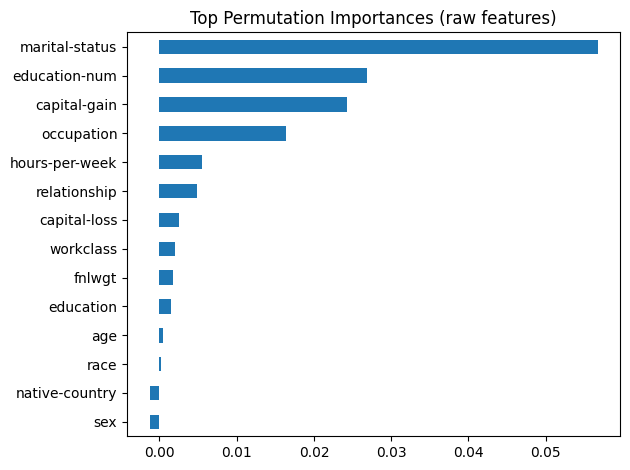

In [11]:
# pick best by ROC-AUC (fallback to F1 if NaN)
def rank_key(k):
    s = scores[k]
    roc = s['roc_auc'] if not np.isnan(s['roc_auc']) else -1.0
    return (roc, s['f1'])

best_name = max(scores, key=rank_key)
best_final = best_models[best_name]
print('Best model:', best_name)

# Compute permutation importance on original features (not one-hot expanded)
perm = permutation_importance(best_final, X_test, y_test,
                              n_repeats=5, random_state=42, n_jobs=-1)

# Use raw feature names from X_test
imp = pd.Series(perm.importances_mean, index=X_test.columns) \
         .sort_values(ascending=False).head(20)

ax = imp.plot(kind="barh"); ax.invert_yaxis()
plt.title("Top Permutation Importances (raw features)")
plt.tight_layout()
plt.savefig(REPORTS / "permutation_importances.png")
plt.show()

imp.to_frame("importance").head(20)


# TODO CHECK:
# Option 2 — if you really want each one-hot column
# You can manually transform X first, then run permutation on the classifier inside:
# Transform test data to feature matrix
"""X_test_trans = best_final.named_steps['preprocess'].transform(X_test)
feat_names = best_final.named_steps['preprocess'].get_feature_names_out()

# Compute permutation importance on transformed data and the classifier
clf = best_final.named_steps['clf']
perm = permutation_importance(clf, X_test_trans, y_test, n_repeats=5, random_state=42, n_jobs=-1)

imp = pd.Series(perm.importances_mean, index=feat_names).sort_values(ascending=False).head(20)"""



## 7) Save final model

In [12]:

joblib.dump(best_final, MODELS / 'final_model.joblib')
MODELS / 'final_model.joblib'


PosixPath('/home/AnirSaddik/Desktop/Year3/Semester1/Data5/Term1/Project/to-check-poject/Fixed_Simple_Adult_Project/notebooks/models/final_model.joblib')


## 8) What else to try (kept simple)
- Add Gradient Boosting (XGBoost/LightGBM/CatBoost).
- Small RandomizedSearchCV over a few params.
- Calibration if you need calibrated probabilities.
- Fairness checks by subgroup (e.g., sex/race).
